# Cell-type heads and supervised refinement

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ashford-A/UniVI/blob/main/docs/tutorials/supervised_heads.ipynb)

UniVI's generative model is unsupervised, but many projects have labels for some cells: annotated cell types, genotypes, disease status. Classification heads are small networks on the latent space that predict those labels. This notebook shows the two ways to use them:

1. **Refine a trained reference** (recommended): attach a head, train it with the encoders frozen, then fine-tune the encoders gently while the decoders stay fixed. Missing labels are simply masked. This is the workflow behind the refined bridge (Fig. 5) and the AML mutation heads (Fig. 7) in the paper.
2. **Train a head jointly** with the VAE from the start.

To make it realistic, only 20% of training cells are labeled.

In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install -q "univi[tutorials]>=1.0"

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import torch

import univi.datasets as uds
from univi import (ClassHeadConfig, ModalityConfig, RefinementConfig, TrainingConfig, UniVIConfig,
                   UniVIMultiModalVAE, UniVIRefiner, UniVITrainer, predict_heads_adata)
from univi.evaluation import encode_adata, label_transfer_knn
from univi.preprocessing import ATACPreprocessor, RNAPreprocessor, split_by_label
from univi.utils.seed import set_seed
from univi.workflows import make_loader, save_reference

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
set_seed(0)

C:\Users\ashfo\micromamba\envs\univi-release-050\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
N_EPOCHS = 400        # unsupervised reference training
REFINE_EPOCHS = 300   # head warmup + encoder fine-tuning
BATCH_SIZE = 256
N_HVG = 2000
N_LSI = 101
LABELED_FRACTION = 0.2

## Train an unsupervised reference

The same setup as the quickstart.

In [4]:
data = uds.pbmc_multiome_10k()
rna, atac = data["rna"], data["atac"]
splits = split_by_label(rna.obs["cell_type"], train_fraction=0.8, val_fraction=0.1, seed=0)
rna_prep = RNAPreprocessor(n_hvg=N_HVG, scale=True).fit(rna[splits["train"]])
atac_prep = ATACPreprocessor(n_components=N_LSI, drop_first=True, scale=True).fit(atac[splits["train"]])
parts = {k: {"rna": rna_prep.transform(rna[i]), "atac": atac_prep.transform(atac[i])} for k, i in splits.items()}
train, val, test = parts["train"], parts["val"], parts["test"]

cfg = UniVIConfig(
    latent_dim=30, beta=1.25, gamma=4.35, encoder_dropout=0.10, decoder_dropout=0.05,
    kl_anneal_start=50, kl_anneal_end=85, align_anneal_start=75, align_anneal_end=110,
    modalities=[ModalityConfig("rna", train["rna"].n_vars, [512, 256, 128], [128, 256, 512]),
                ModalityConfig("atac", train["atac"].n_vars, [128, 64], [64, 128])],
)
model = UniVIMultiModalVAE(cfg, loss_mode="v1", v1_recon="avg", normalize_v1_terms=True)
UniVITrainer(model, make_loader(train, batch_size=BATCH_SIZE, shuffle=True, drop_last=True),
             make_loader(val, batch_size=1024),
             TrainingConfig(n_epochs=N_EPOCHS, batch_size=BATCH_SIZE, lr=1e-3, weight_decay=1e-4, device=device,
                            early_stopping=True, patience=50, best_epoch_warmup=110, log_every=50)).fit();

[2026-09-21 00:45:07,339] [UniVITrainer] [INFO] TrainingConfig:


[2026-09-21 00:45:07,339] [UniVITrainer] [INFO]   n_epochs: 400


[2026-09-21 00:45:07,340] [UniVITrainer] [INFO]   batch_size: 256


[2026-09-21 00:45:07,340] [UniVITrainer] [INFO]   lr: 0.001


[2026-09-21 00:45:07,340] [UniVITrainer] [INFO]   weight_decay: 0.0001


...

Training UniVI:  52%|█████▏    | 209/400 [03:34<03:15,  1.02s/it, beta=1.250, gamma=4.350, train_loss=870.1036, val_loss=895.0386]

Training UniVI:  52%|█████▏    | 209/400 [03:35<03:15,  1.02s/it, beta=1.250, gamma=4.350, train_loss=871.3181, val_loss=893.1917]

[2026-09-21 00:48:43,306] [UniVITrainer] [INFO] Early stopping at epoch 210 (best val loss=892.0657, best epoch=160)


Training UniVI:  52%|█████▏    | 209/400 [03:35<03:17,  1.03s/it, beta=1.250, gamma=4.350, train_loss=871.3181, val_loss=893.1917]


[2026-09-21 00:48:43,338] [UniVITrainer] [INFO] Restored best model from epoch 160 (val loss=892.0657)


## Encode labels, hiding most of them

Heads take integer codes. Unlabeled cells get `-1`, the default `ignore_index`, and contribute nothing to the supervised loss.

In [5]:
classes = sorted(rna.obs["cell_type"].astype(str).unique())
code = {c: i for i, c in enumerate(classes)}

def codes(adata):
    return adata.obs["cell_type"].astype(str).map(code).to_numpy()

y_train = codes(train["rna"])
hidden = np.random.default_rng(0).random(len(y_train)) > LABELED_FRACTION
y_train_partial = np.where(hidden, -1, y_train)
print(f"{(y_train_partial >= 0).sum()} of {len(y_train)} training cells labeled")

1604 of 7698 training cells labeled


## 1. Refine the reference with a head

`add_classification_head` attaches a head without touching the trained weights. `UniVIRefiner` then trains in two stages:

- **warmup**: only the head learns; encoders and decoders are frozen
- **fine-tuning**: the chosen encoders also update, at a much smaller learning rate

Decoders stay frozen throughout, and two optional terms keep the latent space from drifting: `latent_weight` penalizes moving cells away from their original positions, and `replay_weight` keeps optimizing the original unsupervised objective on paired data.

Passing three loaders (paired, RNA-only, ATAC-only) teaches the head to classify from either modality alone, which is what you need for unimodal query data.

In [6]:
model.add_classification_head(
    ClassHeadConfig("cell_type", n_classes=len(classes), hidden_dims=[64, 64, 32],
                    dropout=0.1, batchnorm=False, layernorm=True),
    label_names=classes,
)

labels_train = {"cell_type": y_train_partial}
labels_val = {"cell_type": codes(val["rna"])}
train_loaders = [
    make_loader(train, labels=labels_train, batch_size=BATCH_SIZE, shuffle=True),
    make_loader({"rna": train["rna"]}, labels=labels_train, batch_size=BATCH_SIZE, shuffle=True),
    make_loader({"atac": train["atac"]}, labels=labels_train, batch_size=BATCH_SIZE, shuffle=True),
]
val_loaders = [make_loader({"rna": val["rna"]}, labels=labels_val, batch_size=1024),
               make_loader({"atac": val["atac"]}, labels=labels_val, batch_size=1024)]

refiner = UniVIRefiner(
    model, train_loaders, val_loaders, device=device,
    replay_loader=make_loader(train, batch_size=BATCH_SIZE, shuffle=True, drop_last=True),
    config=RefinementConfig(max_epochs=REFINE_EPOCHS, warmup_epochs=min(50, REFINE_EPOCHS),
                            lr_head=3e-4, lr_encoder=1e-5, latent_weight=1.0, replay_weight=1.0,
                            patience=30, log_every=50),
)
result = refiner.fit()
print("best epoch:", result["best_epoch"])

Refinement 0: heads, validation=1.56666


Refinement 50: encoders+heads, validation=0.23209


best epoch: 62


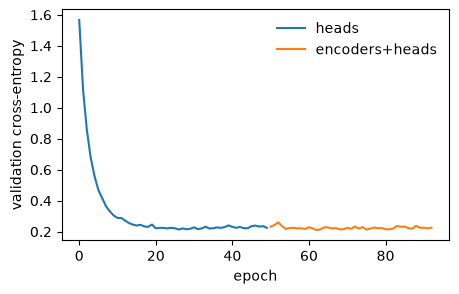

In [7]:
hist = pd.DataFrame(result["history"])
fig, ax = plt.subplots(figsize=(5, 3))
for stage, part in hist.groupby("stage", sort=False):
    ax.plot(part["epoch"], part["val_supervised_loss"], label=stage)
ax.set(xlabel="epoch", ylabel="validation cross-entropy")
ax.legend(frameon=False)
plt.show()

## Predict labels for test cells from one modality

`predict_heads_adata` returns class probabilities per head, in the row order of the input.

In [8]:
y_test = codes(test["rna"])
scores = {}
for mod in ["rna", "atac"]:
    proba = predict_heads_adata(model, test[mod], mod, device=device)["cell_type"]
    scores[f"head, from {mod}"] = (proba.argmax(1) == y_test).mean()
    test[mod].obs["predicted"] = pd.Categorical(np.asarray(classes)[proba.argmax(1)])
    test[mod].obs["confidence"] = proba.max(1)

# Baseline: k-NN label transfer from the same labeled training cells (original, unrefined latent space).
labeled = y_train_partial >= 0
z_lab = encode_adata(refiner.teacher, train["rna"][labeled], modality="rna", device=device, latent="modality_mean")
for mod in ["rna", "atac"]:
    z = encode_adata(refiner.teacher, test[mod], modality=mod, device=device, latent="modality_mean")
    _, acc, _ = label_transfer_knn(z_lab, y_train[labeled], z, y_test, k=15)
    scores[f"k-NN, from {mod}"] = acc
pd.Series(scores, name="test accuracy").round(3)

head, from rna     0.929
head, from atac    0.941
k-NN, from rna     0.918
k-NN, from atac    0.929
Name: test accuracy, dtype: float64

`refiner.teacher` is an untouched copy of the model from before refinement, handy for comparisons like this one.

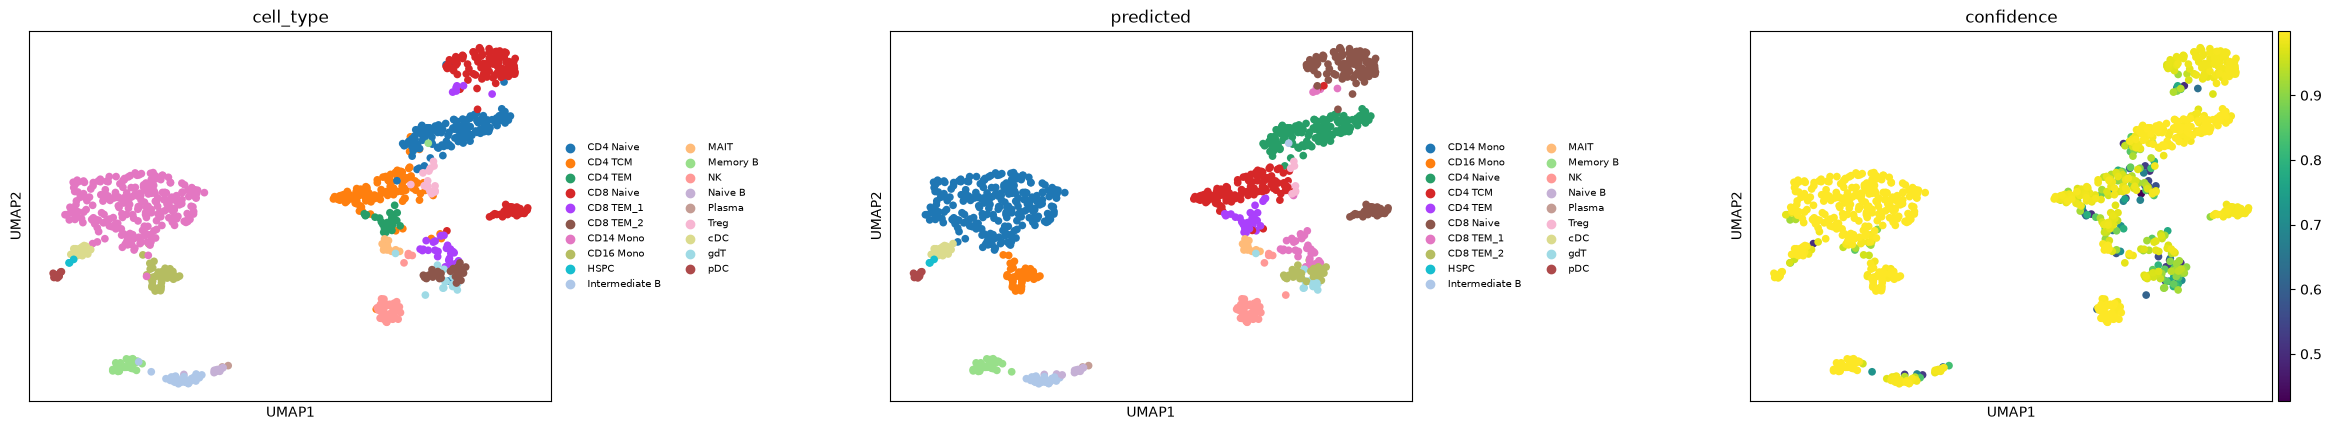

In [9]:
atac_test = test["atac"]
atac_test.obsm["X_univi"] = encode_adata(model, atac_test, modality="atac", device=device, latent="modality_mean")
sc.pp.neighbors(atac_test, use_rep="X_univi")
sc.tl.umap(atac_test, random_state=0)
sc.pl.umap(atac_test, color=["cell_type", "predicted", "confidence"], wspace=0.5, legend_fontsize=7)

Low-confidence predictions concentrate at boundaries between related cell types, which is where manual review pays off.

The refined model, head, and label vocabulary save together:

In [10]:
save_reference("univi_multiome_celltype_head", model, preprocessors={"rna": rna_prep, "atac": atac_prep},
               metadata={"head": "cell_type", "labeled_fraction": LABELED_FRACTION})

## 2. Train a head jointly from the start

Declare heads in `UniVIConfig(class_heads=...)` and pass labels to the loader. The head loss is added to the VAE objective, so the latent space is shaped by the labels from the beginning. This is simpler but lets labels influence the whole embedding, which is less desirable when you want an unsupervised reference that you annotate afterwards.

In [11]:
joint_cfg = UniVIConfig(
    latent_dim=30, beta=1.25, gamma=4.35, encoder_dropout=0.10, decoder_dropout=0.05,
    kl_anneal_start=50, kl_anneal_end=85, align_anneal_start=75, align_anneal_end=110,
    modalities=cfg.modalities,
    class_heads=[ClassHeadConfig("cell_type", n_classes=len(classes), loss_weight=1.0, hidden_dims=[64, 32])],
)
joint_model = UniVIMultiModalVAE(joint_cfg, loss_mode="v1", v1_recon="avg", normalize_v1_terms=True)
joint_model.set_head_label_names("cell_type", classes)
UniVITrainer(joint_model,
             make_loader(train, labels=labels_train, batch_size=BATCH_SIZE, shuffle=True, drop_last=True),
             make_loader(val, labels=labels_val, batch_size=1024),
             TrainingConfig(n_epochs=N_EPOCHS, batch_size=BATCH_SIZE, lr=1e-3, weight_decay=1e-4, device=device,
                            early_stopping=True, patience=50, best_epoch_warmup=110, log_every=100)).fit();
proba = predict_heads_adata(joint_model, test["atac"], "atac", device=device)["cell_type"]
print(f"jointly trained head, from atac: accuracy {(proba.argmax(1) == y_test).mean():.3f}")

[2026-09-21 00:53:30,565] [UniVITrainer] [INFO] TrainingConfig:


[2026-09-21 00:53:30,565] [UniVITrainer] [INFO]   n_epochs: 400


[2026-09-21 00:53:30,566] [UniVITrainer] [INFO]   batch_size: 256


[2026-09-21 00:53:30,566] [UniVITrainer] [INFO]   lr: 0.001


[2026-09-21 00:53:30,566] [UniVITrainer] [INFO]   weight_decay: 0.0001


...

Training UniVI:  45%|████▌     | 180/400 [03:58<04:47,  1.30s/it, beta=1.250, gamma=4.350, train_loss=874.8190, val_loss=895.2806]

[2026-09-21 00:57:28,724] [UniVITrainer] [INFO] Early stopping at epoch 181 (best val loss=892.6403, best epoch=131)


Training UniVI:  45%|████▌     | 180/400 [03:58<04:51,  1.32s/it, beta=1.250, gamma=4.350, train_loss=874.8190, val_loss=895.2806]


[2026-09-21 00:57:28,760] [UniVITrainer] [INFO] Restored best model from epoch 131 (val loss=892.6403)


jointly trained head, from atac: accuracy 0.933


Other head options in `ClassHeadConfig`:

- `head_type="binary"` with `n_classes=2` for yes/no targets such as a mutation call (`pos_weight` rebalances rare positives)
- `adversarial=True` with `adv_lambda` for a gradient-reversal head that pushes a nuisance variable (for example batch) *out* of the latent space during joint training
- several heads at once: pass a dict of label arrays keyed by head name, with `-1` wherever a label is unknown